# Inference of Unknown Dynamical Components Using NG-RC

This notebook investigates the ability of Next Generation Reservoir Computing (NG-RC) to infer unknown components of the Lorenz-63 system from observed state variables. Using the Lorenz system as a benchmark, the study examines whether NG-RC can reconstruct hidden variables and identify the dominant linear and nonlinear relationships governing the system.

The experiment serves as a proof of concept for subsequent applications to climate data, where NG-RC will be used to infer relationships between observed climate variables and target climate indices.

## Planned Experiments

1. **Lorenz System:** $x, y \rightarrow z$

2. **Lorenz System:** $x, z \rightarrow y$

3. **ENSO Data:** SST, SOI, 200mb Zonal Wind $\rightarrow$ ESPI

## Inference of the Lorenz Variable z from Observed Variables

In [1]:
# Source: LorenzConstLinQuadraticNVARtimedelay-RK23.py

import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp

In [2]:
# Time parameters
dt = 0.025
warmup = 5.0
traintime = 10.0
testtime = 120.0
plottime = 20.0
lyaptime = 1.104

maxtime = warmup + traintime + testtime

# Sample counts
warmup_pts = round(warmup / dt)
traintime_pts = round(traintime / dt)
warmtrain_pts = warmup_pts + traintime_pts
testtime_pts = round(testtime / dt)
maxtime_pts = round(maxtime / dt)
plottime_pts = round(plottime / dt)
lyaptime_pts = round(lyaptime / dt)

print(f"{warmup_pts=}")
print(f"{traintime_pts=}")
print(f"{warmtrain_pts=}")
print(f"{testtime_pts=}")
print(f"{maxtime_pts=}")

warmup_pts=200
traintime_pts=400
warmtrain_pts=600
testtime_pts=4800
maxtime_pts=5400


In [3]:
# NG-RC parameters

d = 2
k = 2

dlin = d * k
dnonlin = dlin * (dlin + 1) // 2
dtot = 1 + dlin + dnonlin

ridge_param = 2.5e-6

t_eval = np.linspace(0, maxtime, maxtime_pts + 1)

print(f"{k=}")
print(f"{dlin=}")
print(f"{dnonlin=}")
print(f"{dtot=}")

k=2
dlin=4
dnonlin=10
dtot=15


In [4]:
def lorenz(t, state, sigma=10.0, beta=8/3, rho=28.0):
    x, y, z = state

    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z

    return [dx, dy, dz]

def generate_lorenz_data(initial_state, t_eval, maxtime):
    return solve_ivp(
        lorenz,
        (0, maxtime),
        initial_state,
        t_eval=t_eval,
        method="RK23"
    )

lorenz_soln = generate_lorenz_data(
    initial_state=[17.67715816276679,
                   12.931379185960404,
                   43.91404334248268],
    t_eval=t_eval,
    maxtime=maxtime
)

In [5]:
def build_labels(k):
    linear_labels = []

    for delay in range(k):
        if delay == 0:
            linear_labels.extend(["x(t)", "y(t)"])
        else:
            linear_labels.extend([
                f"x(t-{delay})",
                f"y(t-{delay})"
            ])

    labels = ["1"] + linear_labels

    for i in range(len(linear_labels)):
        for j in range(i, len(linear_labels)):
            labels.append(
                f"{linear_labels[i]}*{linear_labels[j]}"
            )

    return labels


In [6]:
def build_delay_features(obs, d, k, maxtime_pts):
    dlin = d * k

    features = np.zeros((dlin, maxtime_pts))

    for delay in range(k):
        for j in range(delay, maxtime_pts):
            features[d*delay:d*(delay+1), j] = obs[:, j-delay]

    return features


def build_ngrc_matrix(features, start_idx, end_idx, dlin, dtot):
    ngrc = np.ones((dtot, end_idx - start_idx))

    ngrc[1:dlin+1, :] = features[:, start_idx:end_idx]

    cnt = 0
    for i in range(dlin):
        for j in range(i, dlin):
            ngrc[dlin + 1 + cnt, :] = (
                features[i, start_idx:end_idx] *
                features[j, start_idx:end_idx]
            )
            cnt += 1

    return ngrc


def compute_nrmse(y_true, y_pred):
    return np.sqrt(
        np.mean((y_true - y_pred)**2) /
        np.var(y_true)
    )

In [7]:
def run_ngrc_inference(
    lorenz_soln,
    d,
    k,
    ridge_param,
    warmup_pts,
    warmtrain_pts,
    traintime_pts,
    testtime_pts,
    maxtime_pts
):

    dlin = d * k
    dnonlin = dlin * (dlin + 1) // 2
    dtot = 1 + dlin + dnonlin

    labels = build_labels(k)

    # observed variables
    obs = lorenz_soln.y[0:2, :]

    # delay embedding
    features = build_delay_features(
        obs,
        d,
        k,
        maxtime_pts
    )

    # training matrix
    out_train = build_ngrc_matrix(
        features,
        warmup_pts - 1,
        warmtrain_pts - 1,
        dlin,
        dtot
    )

    # target z
    y_train = np.array([
        lorenz_soln.y[2, warmup_pts:warmtrain_pts]
    ])

    # ridge regression
    W_out = (
        y_train @ out_train.T @
        np.linalg.pinv(
            out_train @ out_train.T +
            ridge_param * np.identity(dtot)
        )
    )

    # train prediction
    y_train_pred = W_out @ out_train

    train_nrmse = compute_nrmse(
        y_train,
        y_train_pred
    )

    # test matrix
    out_test = build_ngrc_matrix(
        features,
        warmtrain_pts - 1,
        maxtime_pts - 1,
        dlin,
        dtot
    )

    # test prediction
    y_test_pred = W_out @ out_test

    y_test = np.array([
        lorenz_soln.y[2, warmtrain_pts:maxtime_pts]
    ])

    test_nrmse = compute_nrmse(
        y_test,
        y_test_pred
    )

    return {
        "train_nrmse": train_nrmse,
        "test_nrmse": test_nrmse,
        "weights": W_out,
        "labels": labels,
        "y_test": y_test,
        "y_test_pred": y_test_pred
    }

In [8]:
def plot_results(result, k=None, ridge=None, n_points=500):

    y_true = result["y_test"]
    y_pred = result["y_test_pred"]
    W_out = result["weights"]
    labels = result["labels"]
    nrmse = result["test_nrmse"]

    subtitle = (
        f"k={k}, ridge={ridge:.1e}, NRMSE={nrmse:.4f}"
        if k is not None and ridge is not None
        else f"NRMSE={nrmse:.4f}"
    )

    importance = np.abs(W_out[0])

    top_n = min(20, len(labels))
    idx = np.argsort(importance)[-top_n:]

    fig, ax = plt.subplots(
        1, 2,
        figsize=(18, 6),
        constrained_layout=True
    )

    # Prediction
    ax[0].plot(y_true[0, :n_points], label="True z")
    ax[0].plot(y_pred[0, :n_points], "--", label="Predicted z")

    ax[0].set_title("Hidden-State Inference")
    ax[0].set_xlabel("Time Step")
    ax[0].set_ylabel("z")
    ax[0].legend()
    ax[0].grid(alpha=0.3)

    # Feature importance
    ax[1].barh(range(top_n), W_out[0, idx])

    ax[1].set_yticks(range(top_n))
    ax[1].set_yticklabels([labels[i] for i in idx])

    ax[1].set_xlabel(r"$W_{out}$")
    ax[1].set_title(f"Top {top_n} Features")
    ax[1].axvline(0, linewidth=0.8)

    fig.suptitle(
        f"NG-RC Hidden Variable Inference | {subtitle}",
        fontsize=14,
        fontweight="bold"
    )

    plt.show()

k= 2 | ridge=1.0e-08 | NRMSE=0.2729


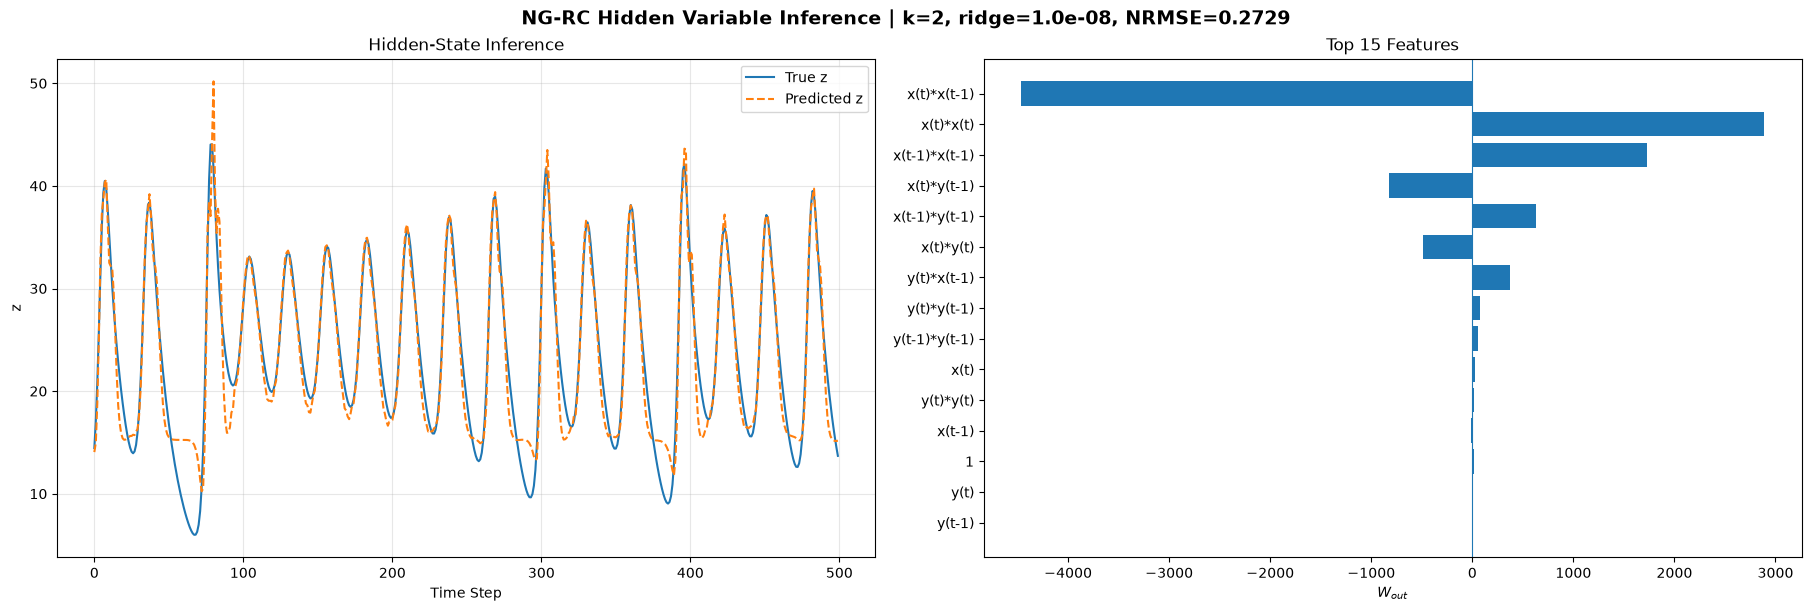

In [9]:
for k in [2]:
    for ridge in [1e-8]:

        result = run_ngrc_inference(
            lorenz_soln,
            d=2,
            k=k,
            ridge_param=ridge,
            warmup_pts=warmup_pts,
            warmtrain_pts=warmtrain_pts,
            traintime_pts=traintime_pts,
            testtime_pts=testtime_pts,
            maxtime_pts=maxtime_pts
        )

        print(
            f"k={k:2d} | "
            f"ridge={ridge:.1e} | "
            f"NRMSE={result['test_nrmse']:.4f}"
        )

        plot_results(
            result,
            k=k,
            ridge=ridge
        )